In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np      
import seaborn as sns

In [2]:
#load the Dataset 
df = pd.read_csv('walmart.csv')
df.head()

,Unnamed: 0,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,False,1.0,24924.50,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,2,1,2010-02-05,False,26.0,11737.12,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
2,3,1,2010-02-05,False,17.0,13223.76,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
3,4,1,2010-02-05,False,45.0,37.44,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
4,5,1,2010-02-05,False,28.0,1085.29,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315


Phase 1:- Data Cleaning


In [3]:
#Checking Null Values
df.isnull().sum()

Unnamed: 0           0
Store                0
Date                 0
IsHoliday            0
Dept              1755
Weekly_Sales      1755
Temperature          0
Fuel_Price           0
MarkDown1       270892
MarkDown2       310793
MarkDown3       284667
MarkDown4       286859
MarkDown5       270138
CPI                585
Unemployment       585
Type                 0
Size                 0
dtype: int64

In [4]:
(df.isnull().mean()*100).sort_values(ascending=False)

MarkDown2       73.417115
MarkDown4       67.763302
MarkDown3       67.245497
MarkDown1       63.991496
MarkDown5       63.813382
Weekly_Sales     0.414575
Dept             0.414575
Unemployment     0.138192
CPI              0.138192
Unnamed: 0       0.000000
Fuel_Price       0.000000
Date             0.000000
IsHoliday        0.000000
Store            0.000000
Temperature      0.000000
Type             0.000000
Size             0.000000
dtype: float64

In [5]:
#Filling Null Values
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

In [6]:
#Converting the 'Dept' column to a categorical data type
df['Dept'] = df['Dept'].astype('category')

In [7]:
#Filling Null Values in 'Unemployment' column using forward fill method
df['Unemployment'] = df['Unemployment'].fillna(method='ffill')

C:\Users\ct\AppData\Local\Temp\ipykernel_5756\1098386563.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Unemployment'] = df['Unemployment'].fillna(method='ffill')


In [8]:
#Filling Null Values in 'CPI' column using forward fill method
df['CPI']= df['CPI'].fillna(method='ffill')

C:\Users\ct\AppData\Local\Temp\ipykernel_5756\1737820608.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['CPI']= df['CPI'].fillna(method='ffill')


In [9]:
#Checking Null Values after filling
(df.isnull().mean()*100).sort_values(ascending=False)

Dept            0.414575
Weekly_Sales    0.414575
Unnamed: 0      0.000000
Date            0.000000
Store           0.000000
IsHoliday       0.000000
Temperature     0.000000
Fuel_Price      0.000000
MarkDown1       0.000000
MarkDown2       0.000000
MarkDown3       0.000000
MarkDown4       0.000000
MarkDown5       0.000000
CPI             0.000000
Unemployment    0.000000
Type            0.000000
Size            0.000000
dtype: float64

In [10]:
#Dropping rows with null values in 'Weekly_Sales' and 'Dept' columns
df=df.dropna(subset=['Weekly_Sales','Dept'])

In [11]:
#Extracting date features from the 'Date' column
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Week'] = df['Date'].dt.isocalendar().week

Exploratory Data Analysis (EDA)

Q.1) Average Weekly Sales By Store.

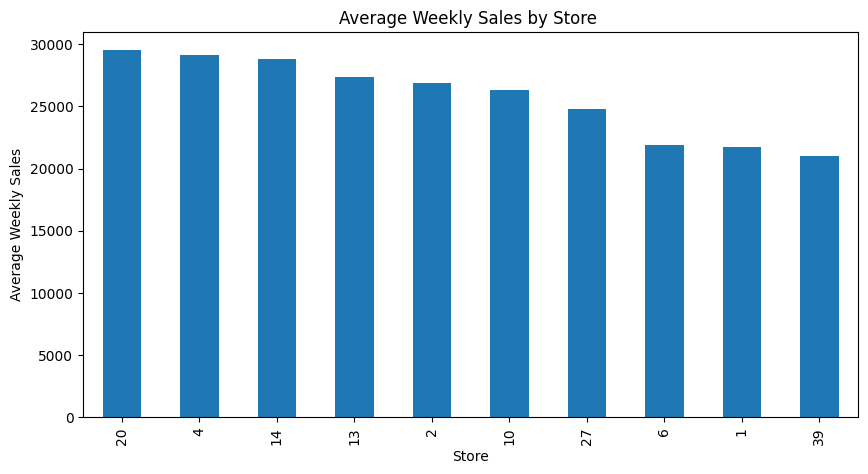

In [12]:
store_avg = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
top10_stores = store_avg.head(10)
plt.figure(figsize=(10,5))
top10_stores.plot(kind='bar')
plt.title("Average Weekly Sales by Store ")
plt.ylabel("Average Weekly Sales")
plt.show()

This graph shows that:

Stores 20 and 4 lead in weekly sales — Walmart should identify and replicate their success factors across underperforming locations.

Q.2) Which Departments Performs Best?

C:\Users\ct\AppData\Local\Temp\ipykernel_5756\1320324315.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  best_dept = df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)


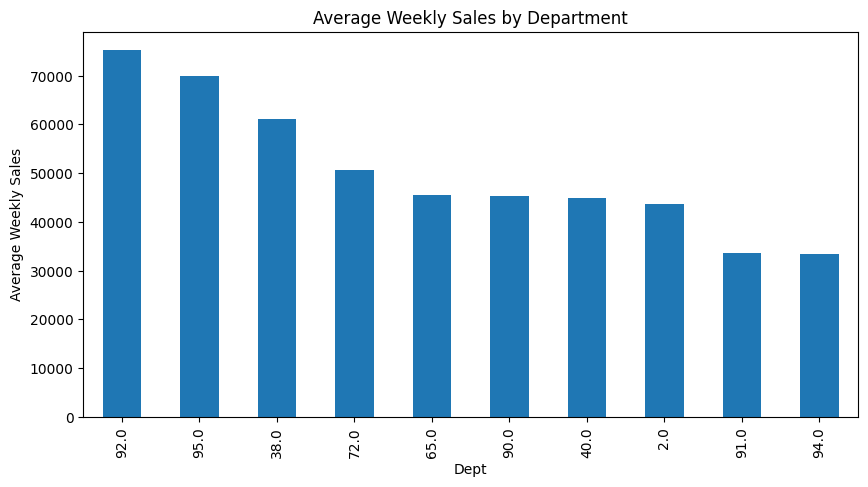

In [13]:
best_dept = df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)
top10_best_depts = best_dept.head(10)
plt.figure(figsize=(10,5))
top10_best_depts.plot(kind='bar')
plt.title("Average Weekly Sales by Department")
plt.ylabel("Average Weekly Sales")
plt.show()

This Graaph show us:

Departments 92 and 95 dominate revenue — prioritize their inventory, staffing, and shelf space for maximum return.

Q.3) Weekly Sales Distributed

In [14]:
df['Weekly_Sales'].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

<Axes: xlabel='Weekly_Sales', ylabel='Count'>

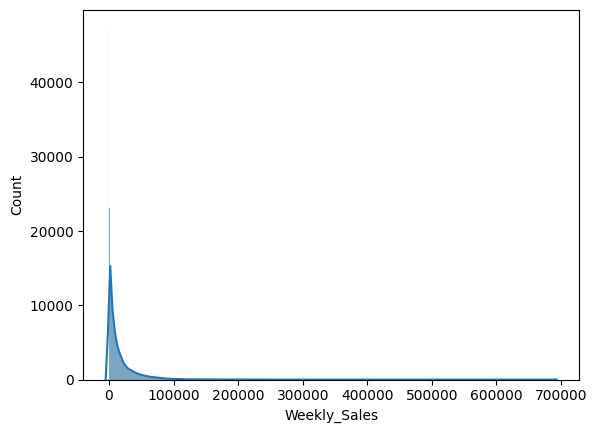

In [15]:
sns.histplot(df['Weekly_Sales'], kde=True)

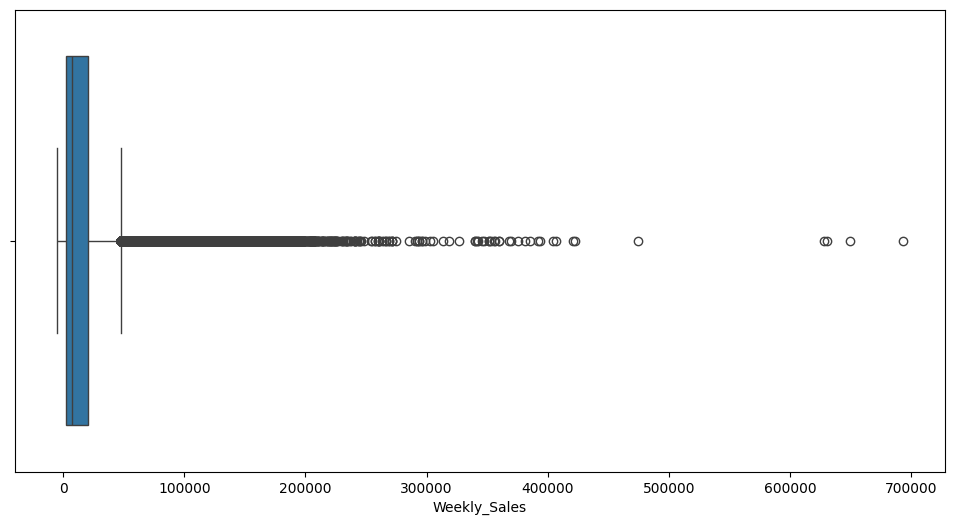

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(x=df['Weekly_Sales'])
plt.show()

Q.4) Sales Ratio

For Weekly Sales

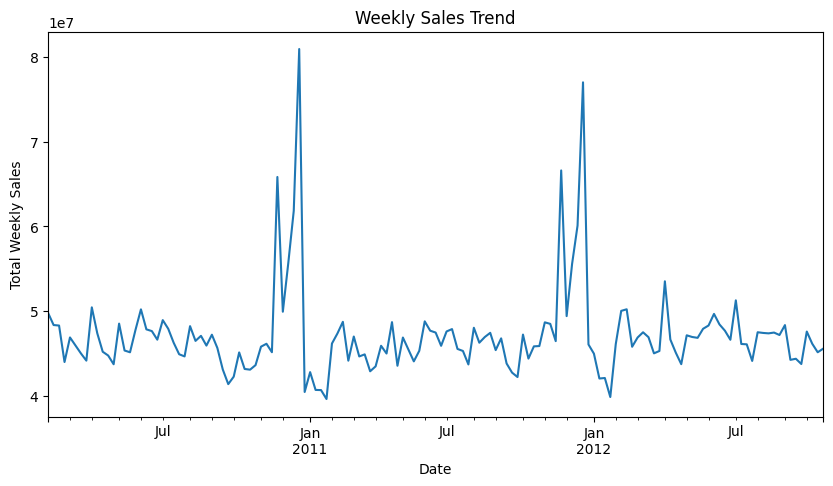

In [17]:
weekly_trend = df.groupby('Date')['Weekly_Sales'].sum()
plt.figure(figsize=(10,5))
weekly_trend.plot()
plt.title("Weekly Sales Trend")
plt.ylabel("Total Weekly Sales")
plt.show()

For Monthly Trend

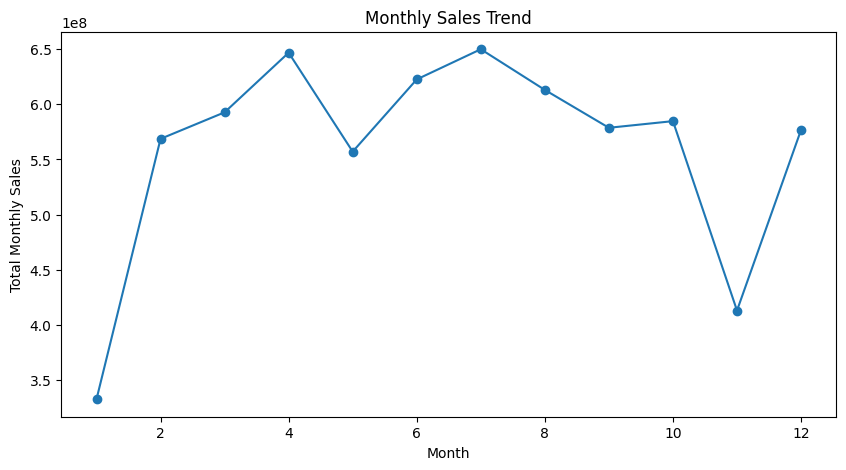

In [18]:
monthly_trend = df.groupby('Month')['Weekly_Sales'].sum()
plt.figure(figsize=(10,5))
monthly_trend.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Total Monthly Sales")
plt.show()

This Shows that:

Sales spike in Nov–Dec and dip in Jan–Feb — stock up and staff up from October, then use January for clearance."

For Year Trend

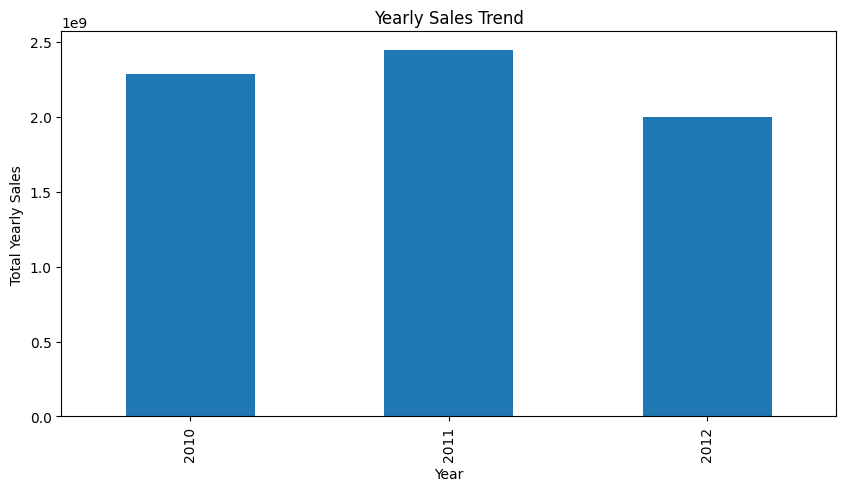

In [19]:
yearly_trend = df.groupby('Year')['Weekly_Sales'].sum()
plt.figure(figsize=(10,5))
yearly_trend.plot(kind='bar')
plt.title("Yearly Sales Trend")
plt.ylabel("Total Yearly Sales")
plt.show()

Q.5) Holiday effect on sales

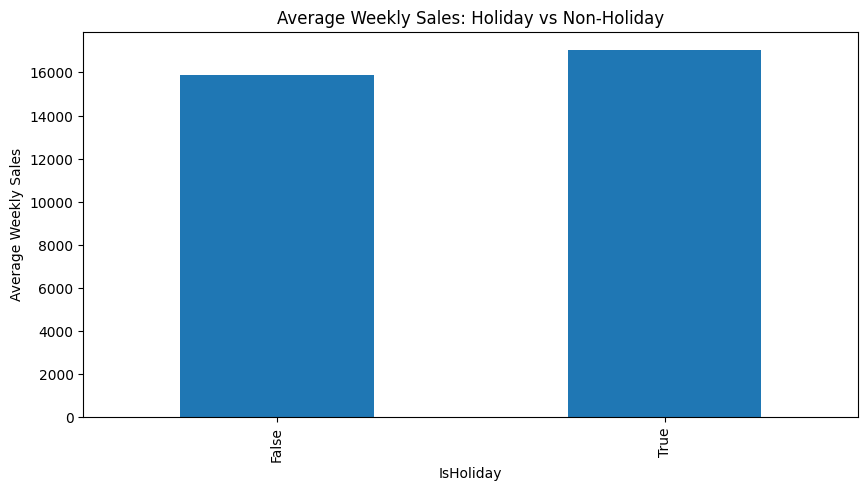

In [20]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()
plt.figure(figsize=(10,5))
holiday_sales.plot(kind='bar')
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.ylabel("Average Weekly Sales")
plt.show()

This shows us that:

Non-holiday weeks outperform holiday weeks on average — suggesting current holiday promotions need a strategic rethink to drive real incremental revenue.

Unemployement effect on Sales

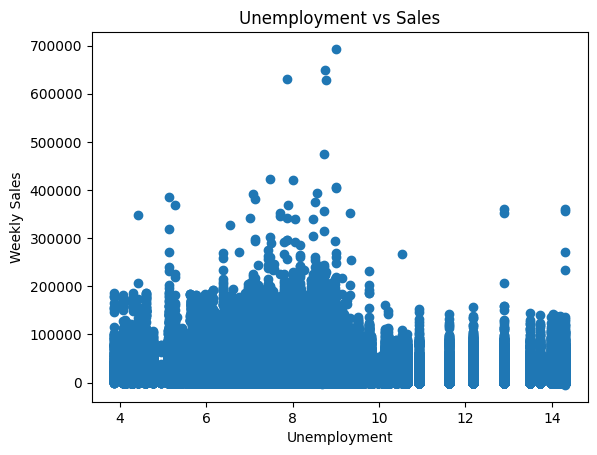

In [21]:
df[['Weekly_Sales','Unemployment']].corr()
plt.scatter(df['Unemployment'], df['Weekly_Sales'])
plt.xlabel("Unemployment")
plt.ylabel("Weekly Sales")
plt.title("Unemployment vs Sales")
plt.show()

Rising Fuel Prices

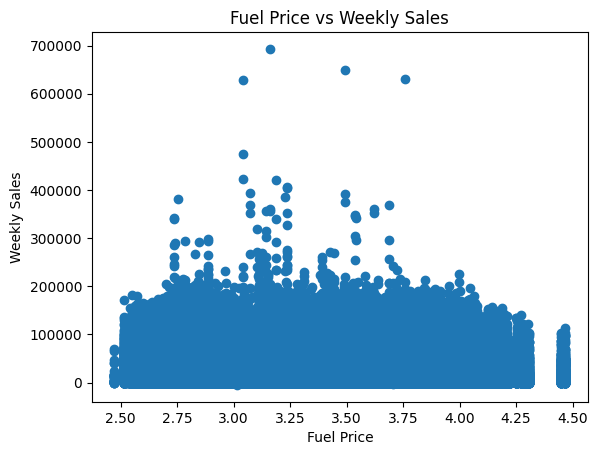

In [22]:
df[['Weekly_Sales','Fuel_Price']].corr()
plt.scatter(df['Fuel_Price'], df['Weekly_Sales'])
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")
plt.title("Fuel Price vs Weekly Sales")
plt.show()

CPI On Sales


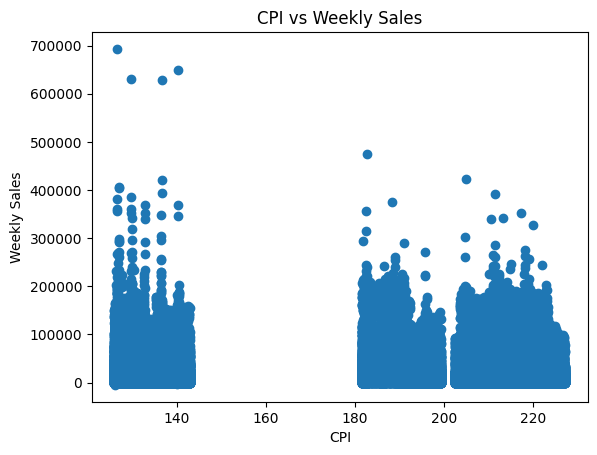

In [23]:
df[['Weekly_Sales','CPI']].corr()
plt.scatter(df['CPI'], df['Weekly_Sales'])  
plt.xlabel("CPI")
plt.ylabel("Weekly Sales")
plt.title("CPI vs Weekly Sales")
plt.show()

Effect Of Temperature

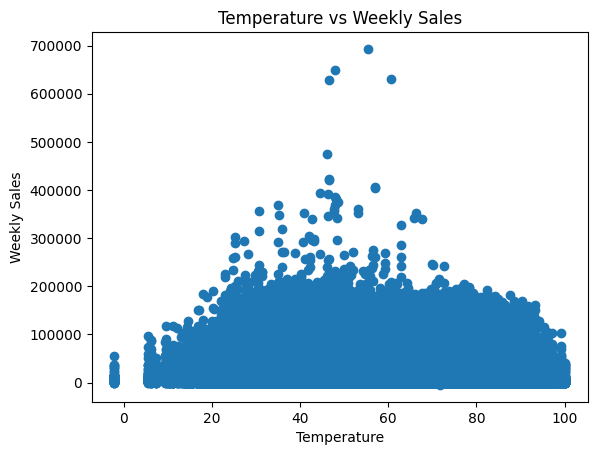

In [24]:
df[['Weekly_Sales','Temperature']].corr()
plt.scatter(df['Temperature'], df['Weekly_Sales'])
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.title("Temperature vs Weekly Sales")
plt.show()

Showing relation of these combine

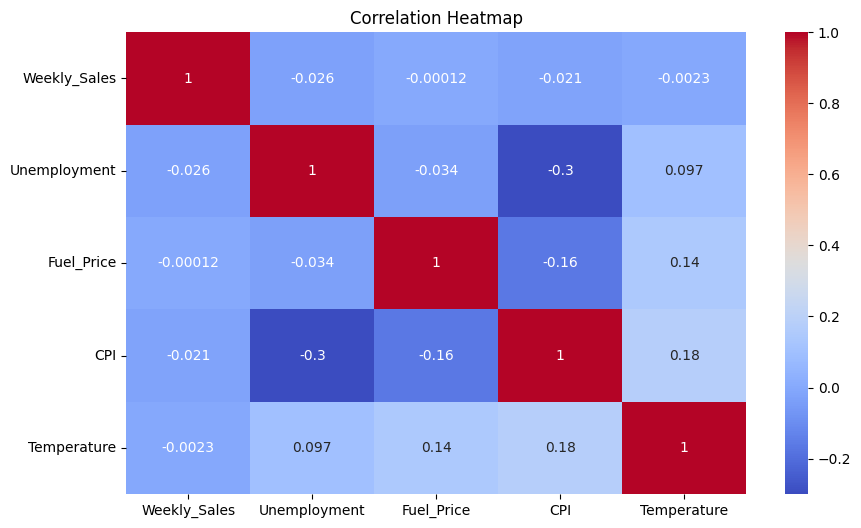

In [25]:
corr = df[['Weekly_Sales','Unemployment','Fuel_Price','CPI','Temperature']].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

THis Whole shows us that:

Unemployment, CPI, and fuel prices have minimal impact on sales confirming Walmart's value-pricing model keeps customers resilient to economic shifts.

MarkDown Effect On Sales

Correlation: 0.06523650265818393


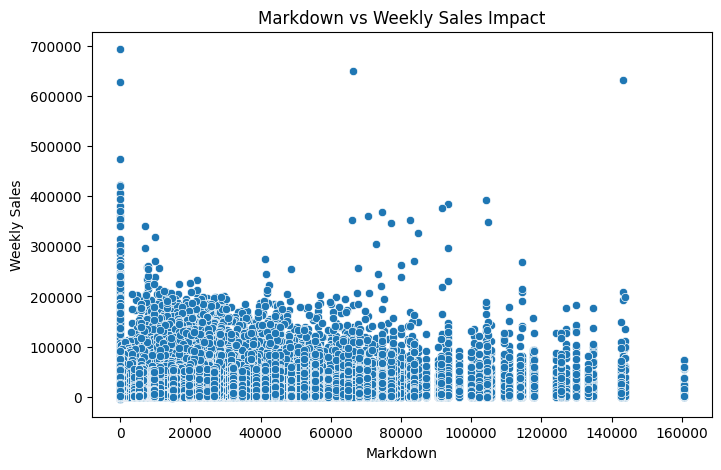

In [26]:
Markdown = df['MarkDown1'] + df['MarkDown2'] + df['MarkDown3'] + df['MarkDown4'] + df['MarkDown5']
correlation = Markdown.corr(df['Weekly_Sales'])
print(f"Correlation: {correlation}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=Markdown, y=df['Weekly_Sales'])
plt.title('Markdown vs Weekly Sales Impact')
plt.xlabel('Markdown')
plt.ylabel('Weekly Sales')
plt.show()

This Graph shows us that:

Markdowns show weak correlation with sales blanket discounting isn't working; timing promotions around peak seasons would be more effective.

Section 5
Q.1) Which store generates highest sales?

In [27]:
df.head()

,Unnamed: 0,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Day,Week
0,1,1,2010-02-05,False,1.0,24924.50,42.31,2.572,0.0,0.0,...,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,5
1,2,1,2010-02-05,False,26.0,11737.12,42.31,2.572,0.0,0.0,...,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,5
2,3,1,2010-02-05,False,17.0,13223.76,42.31,2.572,0.0,0.0,...,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,5
3,4,1,2010-02-05,False,45.0,37.44,42.31,2.572,0.0,0.0,...,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,5
4,5,1,2010-02-05,False,28.0,1085.29,42.31,2.572,0.0,0.0,...,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,5


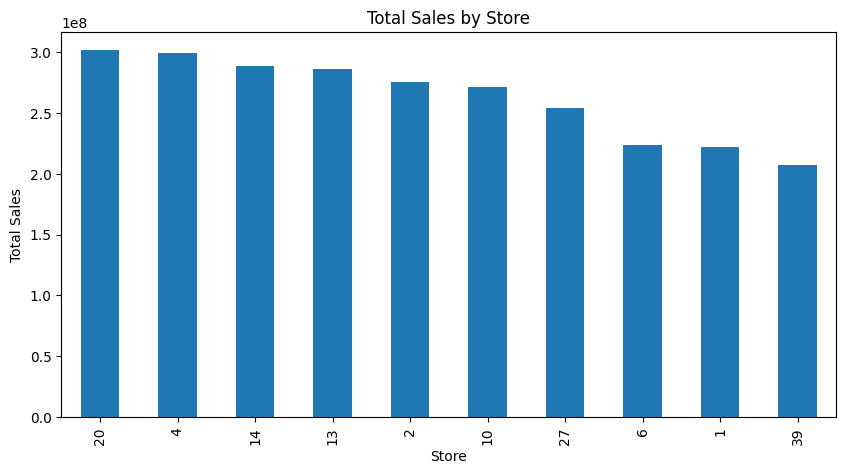

In [28]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
top10_stores = store_sales.head(10)
plt.figure(figsize=(10,5))
top10_stores.plot(kind='bar')
plt.title("Total Sales by Store")
plt.ylabel("Total Sales")
plt.show()

Best Stores and Worst Stores


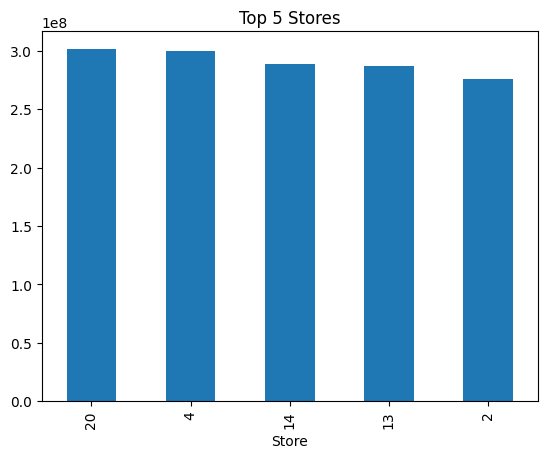

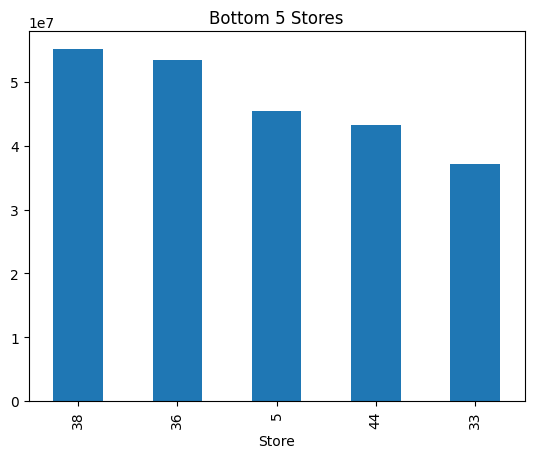

In [29]:
store_sales.head(5).plot(kind='bar')
plt.title("Top 5 Stores")
plt.show()

store_sales.tail(5).plot(kind='bar')
plt.title("Bottom 5 Stores")
plt.show()

In [30]:
df.to_csv("walmart_cleaned.csv", index=False)